# Проект: Интерпретируемая классификация ящериц

## Описание

Олимпиадная задача по анализу данных: классификация ящериц рода **Darevskia** по морфометрическим и фолидозным признакам. 
Цель — построить простые и объяснимые правила определения вида и пола без использования моделей типа «черного ящика».

## Что реализовано

* проведен EDA и анализ распределений;
* найдены признаки, разделяющие виды и пол;
* реализован перебор признаков и их комбинаций;
* построены интерпретируемые правила классификации;
* качество оценено через accuracy и матрицы ошибок.

## Стек

**Python**, **Pandas**, **NumPy**, **Matplotlib**, **itertools**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Задача 1

**Условие:**
Создайте критерий, позволяющий наилучшим возможным образом отличать ящериц вида
No5 от всех остальных ящериц и использующий только количество бедренных пор справа
(FPNr).
Подсказка: постройте и изучите распределение ящериц по FPNr в зависимости от их вида.

Построим диаграмму для каждой группы по столбцу FPNr:

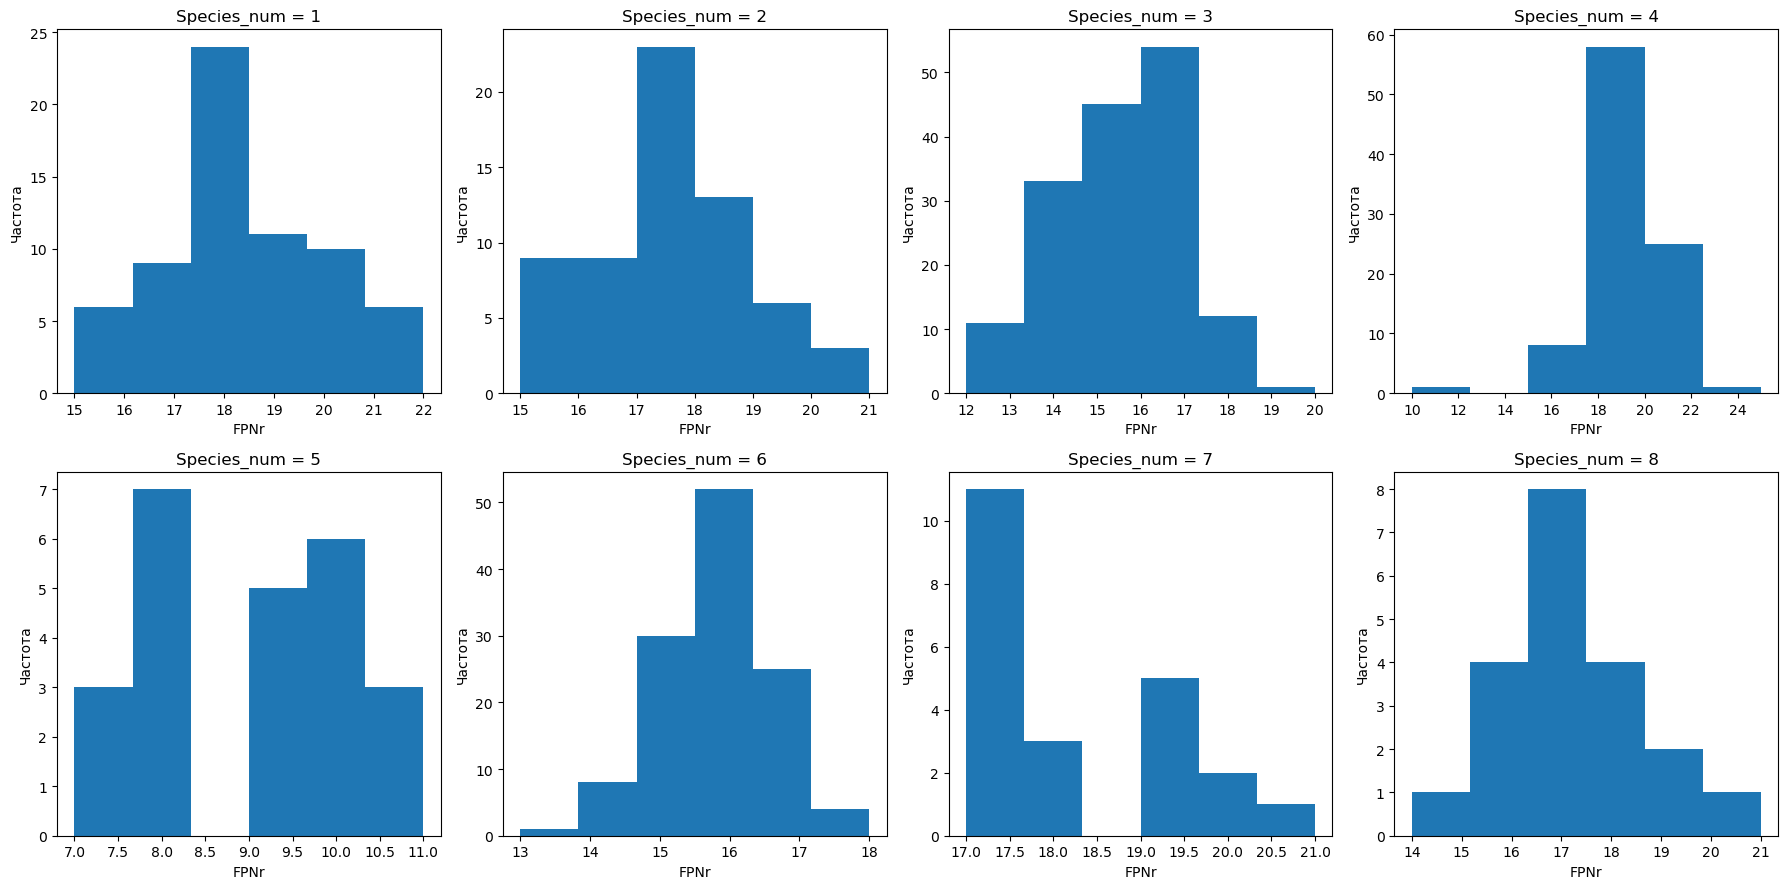

In [2]:
df = pd.read_csv("Ящерицы_данные.csv", sep=';')

# Список из видов
species_values = sorted(df['Species_num'].dropna().unique())

# Создаём поле из 8 графиков (2 строки × 4 столбца)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Строим гистограмму для каждой группы
for ax, species in zip(axes, species_values):
    subset = df[df['Species_num'] == species]
    ax.hist(subset['FPNr'].dropna(), bins=6)
    ax.set_title(f'Species_num = {species}')
    ax.set_xlabel('FPNr')
    ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

Визуально можно обнаружить, что у вида 5 FPNr лежит в интервале [7; 11].

Значения FPNr у других видов не опускаются ниже 11, за исключением выброса (предполагаемого) в 4 группе. 

Поэтому создадим критерий: **Если FPNr <= 11, то Species_num - 5**

In [3]:
# Отделяем 5 вид для будущей проверки
df['species_5'] = (df['Species_num'] == 5).astype(int)

# Условие
cond = 11
print(f"Условие классификации: Если FPNr <= {cond}, то Species_num - 5")

# Присваиваем "1" тем, кто прошел условие, и 0 в противном случае
df['pred_species_5'] = (df['FPNr'] <= cond).astype(int)

# Матрица
a = np.sum((df['pred_species_5'] == 1) & (df['species_5'] == 1))
b = np.sum((df['pred_species_5'] == 1) & (df['species_5'] == 0))
c = np.sum((df['pred_species_5'] == 0) & (df['species_5'] == 1))
d = np.sum((df['pred_species_5'] == 0) & (df['species_5'] == 0))

table = pd.DataFrame([[a, b], [c, d]],
    index = ['Классифицирован как вид №5', 'Классифицирован как вид №1-4, 6-8'],
    columns = ['На самом деле вид №5', 'На самом деле виды №1-4, 6-8'])

print('\nМатрица:')
table

Условие классификации: Если FPNr <= 11, то Species_num - 5

Матрица:


,На самом деле вид №5,"На самом деле виды №1-4, 6-8"
Классифицирован как вид №5,24,1
"Классифицирован как вид №1-4, 6-8",0,539


# Задача 2

**Условие:**
Создайте критерий, позволяющий наилучшим возможным образом отличать ящериц вида
No5 от всех остальных ящериц и использующий две переменных из измеряемых
морфометрических и фолидозных признаков.
Подсказка: одним из способов нахождения наилучшей пары предсказывающих
переменных (предикторов) может быть перебор всех возможных пар переменных.

Воспользуемся подсказкой и с помощью библиотеки itertools и функции *combinations* переберем все возможные комбинации и найдем признаки, которые лучше всего описывают принадлежность к виду 5

Для поиска лучших пар признаков будем проверять принадлежность каждого значения в столбце к интервалу, основанному на распределении вида 5. Далее выберем те признаки, которые показали наибольшую точность

In [4]:
df = pd.read_csv("Ящерицы_данные.csv", sep=';')

# Отделяем 5 вид
df['target'] = (df['Species_num'] == 5).astype(int)

cols = []
for i in df.columns:
    if i in ['Species_num', 'Sex', 'target', 'Sex_num']:
        continue
    else:
        cols.append(i)

# Поиск лучшей пары признаков
best_accuracy = 0
best_pair = []
best_ranges = {}
best_table = []

for col1, col2 in combinations(cols, 2):
    sub = df[[col1, col2, 'target']].dropna()
    species5 = sub[sub['target'] == 1]
    
    # Интервалы:
    # [median - 2*std; median + 2*std]
    med1 = species5[col1].median()
    std1 = species5[col1].std()
    med2 = species5[col2].median()
    std2 = species5[col2].std()

    min1 = med1 - 2*std1
    max1 = med1 + 2*std1
    min2 = med2 - 2*std2
    max2 = med2 + 2*std2

    # Условие
    cond = (sub[col1].between(min1, max1) & sub[col2].between(min2, max2)).astype(int)
    
    # Матрица ошибок
    a = np.sum((cond == 1) & (sub['target'] == 1))
    b = np.sum((cond == 1) & (sub['target'] == 0))
    c = np.sum((cond == 0) & (sub['target'] == 1))
    d = np.sum((cond == 0) & (sub['target'] == 0))
    accuracy = (a + d) / (a + b + c + d)

    if accuracy > best_accuracy:    
        best_accuracy = accuracy
        best_pair = [col1, col2]
        best_ranges = {
            col1: (min1, max1),
            col2: (min2, max2)}
        best_table = [a, b, c, d]


print(f'Лучшая пара признаков: {best_pair} с точностью {best_accuracy}\n')
print(f'''Критерий:
{best_ranges[best_pair[0]][0]:.2f} <= {best_pair[0]} <= {best_ranges[best_pair[0]][1]:.2f} 
И 
{best_ranges[best_pair[1]][0]:.2f} <= {best_pair[1]} <= {best_ranges[best_pair[1]][1]:.2f}''')

# Матрица
print('\nМатрица:')
table = pd.DataFrame(
    [[best_table[0], best_table[1]], [best_table[2], best_table[3]]],
    index=['Классифицирован как вид №5', 'Классифицирован как вид №1-4, 6-8'],
    columns=['На самом деле вид №5', 'На самом деле виды №1-4, 6-8'])
table

Лучшая пара признаков: ['FPNr', 'HL'] с точностью 1.0

Критерий:
6.46 <= FPNr <= 11.54 
И 
14.51 <= HL <= 18.89

Матрица:


,На самом деле вид №5,"На самом деле виды №1-4, 6-8"
Классифицирован как вид №5,24,0
"Классифицирован как вид №1-4, 6-8",0,540


# Задача 3

**Условие:**
Создайте критерий, позволяющий наилучшим возможным образом предсказывать пол
ящериц вне зависимости от их вида по морфометрическим признакам и/или признакам
фолидоза.
Подсказка от биологов: предполагается (но не гарантируется!), что пол будет
взаимосвязан с отношениями некоторых измеряемых длин; но это не исключает участия в
критерии и других предикторов.

Попробуем провести эмпирическое исследование с целью выявить возможные расхождения в показателях

Для этого построим диаграммы, сгруппируя признаки по полу

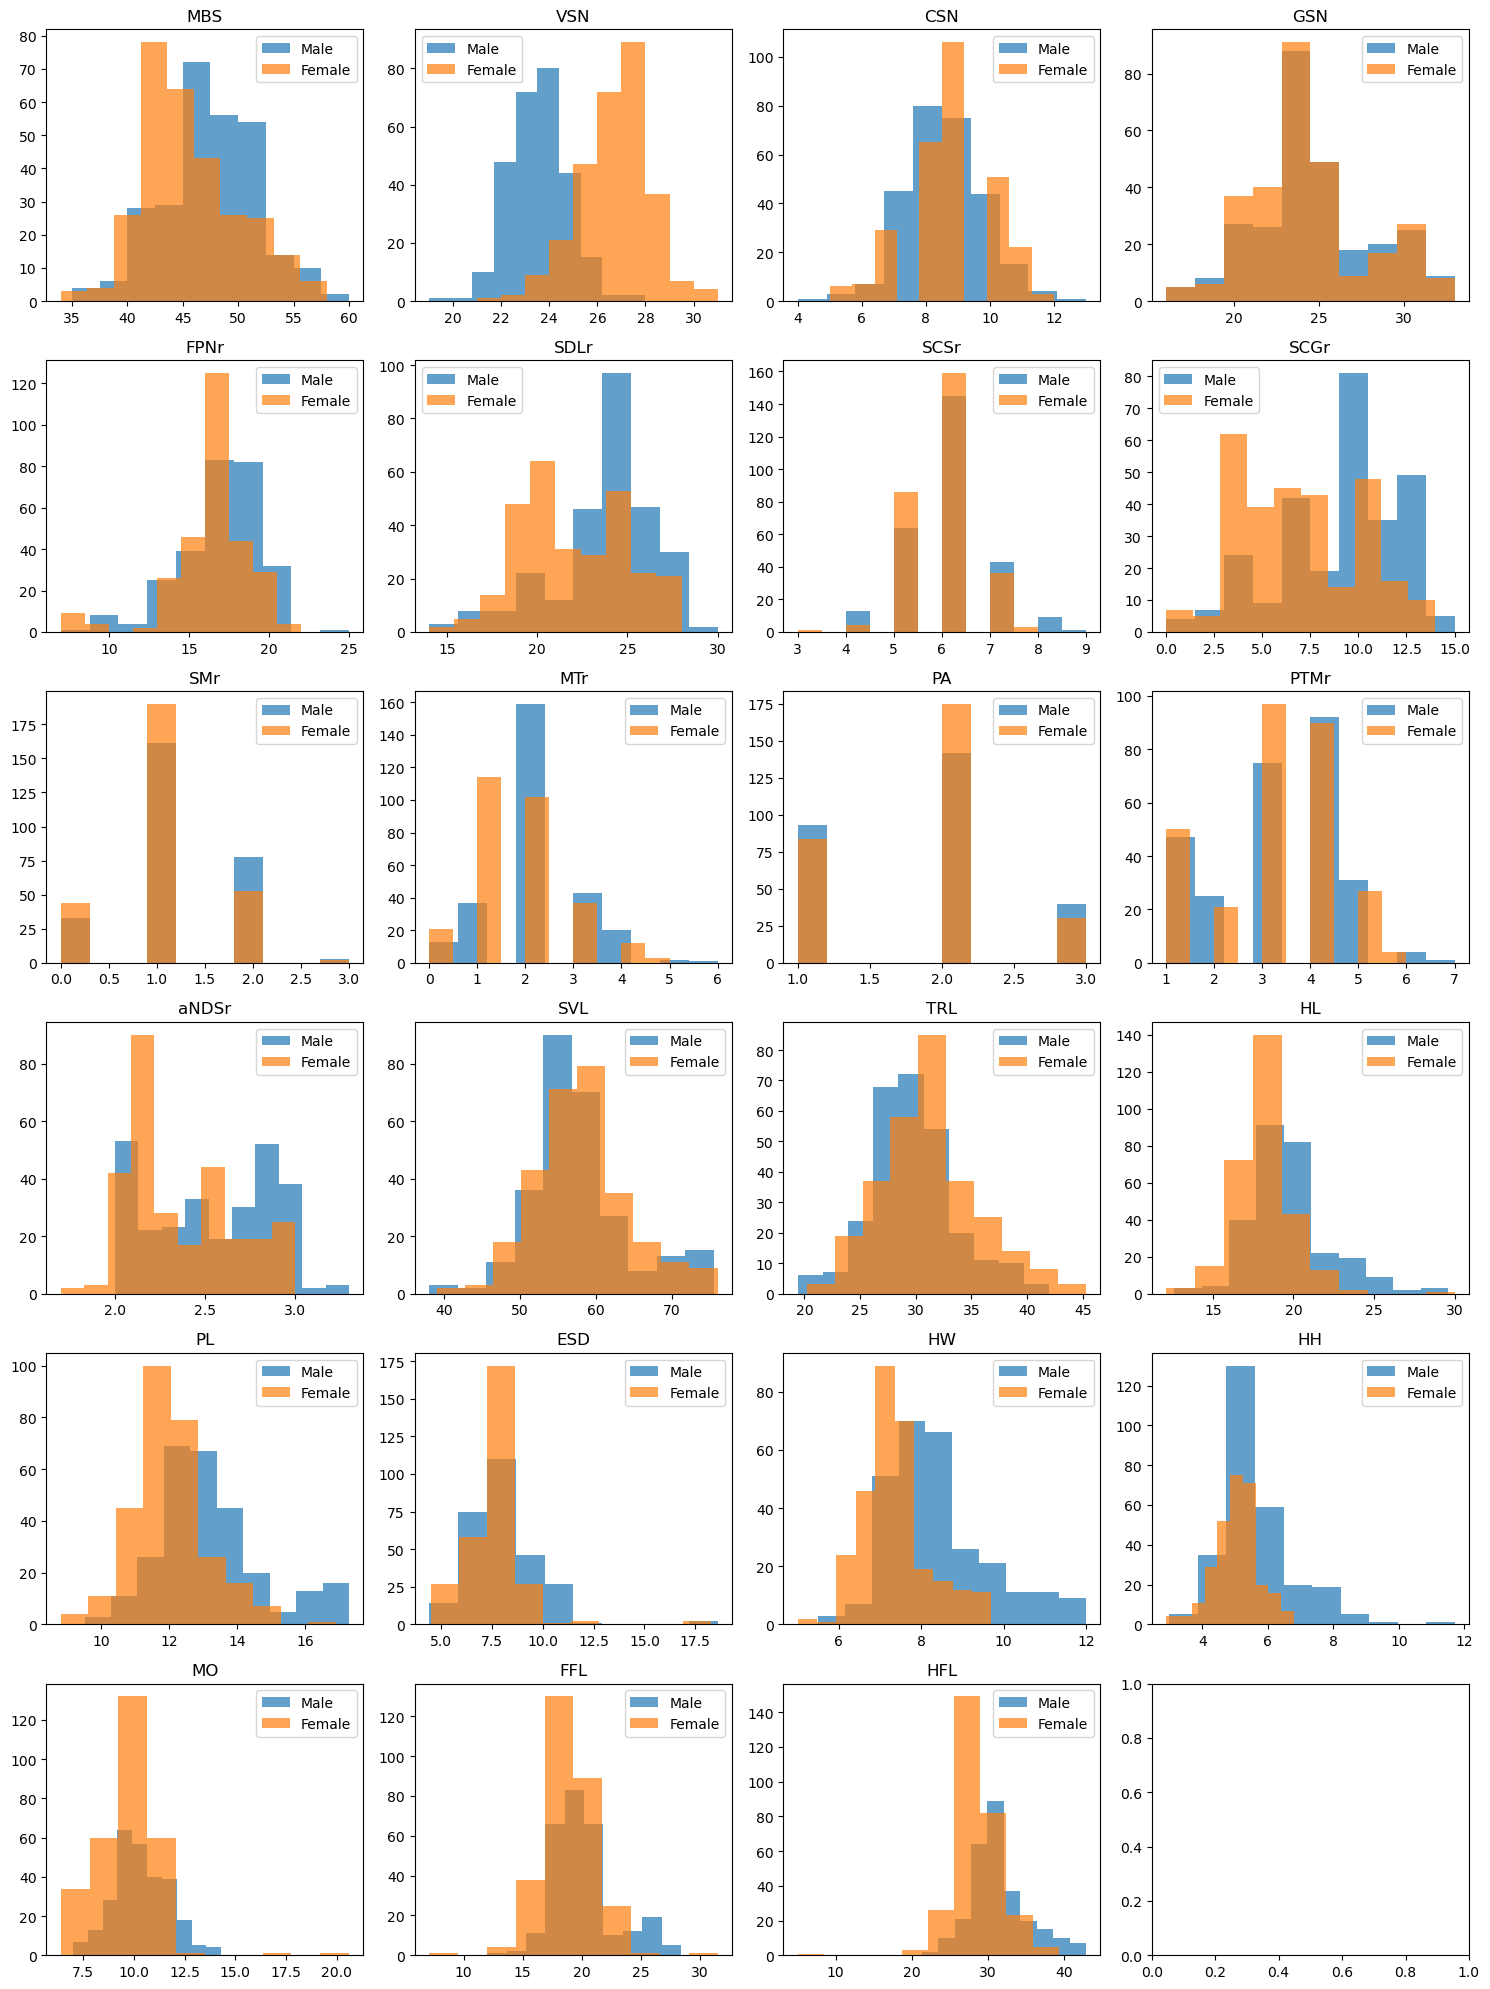

In [5]:
df = pd.read_csv("Ящерицы_данные.csv", sep=';')
cols = []
for i in df.columns:
    if i in ['Species_num', 'Sex', 'Sex_num']:
        continue
    else:
        cols.append(i)

male = df[df['Sex'] == 'M']
female = df[df['Sex'] == 'F']

# Создаем figure
fig, axes = plt.subplots(int(np.ceil(len(cols)/4)), 4, figsize=(15, 20))

axes = axes.flatten()

# Гистограммы
for i, col in enumerate(cols):
    ax = axes[i]
    ax.hist(male[col].dropna(), bins=10, alpha=0.7, label='Male')
    ax.hist(female[col].dropna(), bins=10, alpha=0.7, label='Female')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

Сильных расхождений не обнаружено, кроме VSN, но этого недостаточно, чтобы иметь высокую точность

Поэтому воспользуемся подсказкой и попарно переберем отношение всех морфометрических признаков. И так же выберем самый точный

In [6]:
df = pd.read_csv('Ящерицы_данные.csv', sep=';')

# Морфометрические признаки
morpho = ['SVL', 'TRL', 'HL', 'PL', 'ESD', 'HW', 'HH', 'MO', 'FFL', 'HFL']
true = df['Sex_num'].values

best_accuracy = 0
best_ratio = ''
best_th = 0
best_dir = ''
best_table = []

# Перебираем все пары признаков
for a, b in combinations(morpho, 2):
    # Два отношения: a/b и b/a
    for ratio, name in [(df[a]/df[b], f'{a}/{b}'), (df[b]/df[a], f'{b}/{a}')]:
        vals = ratio.values
        # Все возможные пороги между соседними значениями
        uniq = np.unique(vals)
        for i in range(len(uniq)-1):
            th = (uniq[i] + uniq[i+1]) / 2
            # Проверяем оба направления
            for direction in ['greater', 'less']:
                if direction == 'greater':
                    pred = np.where(vals > th, 1, 2)
                else:
                    pred = np.where(vals < th, 1, 2)
                acc = (pred == true).mean()
                if acc > best_accuracy:
                    best_accuracy = acc
                    best_ratio = name
                    best_th = th
                    best_dir = direction
                    # Сохраняем матрицу ошибок
                    a = np.sum((true==1) & (pred==1))
                    b = np.sum((true==1) & (pred==2))
                    c = np.sum((true==2) & (pred==1))
                    d = np.sum((true==2) & (pred==2))
                    best_table = [a, b, c, d]

# Вывод результатов
print(f'Лучший критерий: {best_ratio} {best_dir} {best_th:.4f}')
print(f'Точность: {best_accuracy:.1%}')
print('\nМатрица:')

table = pd.DataFrame([[best_table[0], best_table[1]], [best_table[2], best_table[3]]],
    index=['Классифицирован как вид №5', 'Классифицирован как вид №1-4, 6-8'],
    columns=['На самом деле вид №5', 'На самом деле виды №1-4, 6-8'])

table

Лучший критерий: SVL/PL less 4.5837
Точность: 90.8%

Матрица:


,На самом деле вид №5,"На самом деле виды №1-4, 6-8"
Классифицирован как вид №5,262,13
"Классифицирован как вид №1-4, 6-8",39,250


# Задача 4

**Условие:**
Не все рассматриваемые виды ящериц встречаются в одних и тех же местах обитания.
Поэтому на практике чаще всего встречаются задачи различения видов из определённых
подгрупп, обитающих совместно. Создайте набор критериев, позволяющих наилучшим
возможным образом отличать друг от друга все виды внутри следующих групп:
a. виды No6 и No7,
b. виды No1 и No2,
c. виды No3, No4 и No5.

Как и в задаче 3 попробуем провести эмпирическое исследование

## Поиск критерия для групп 6 и 7

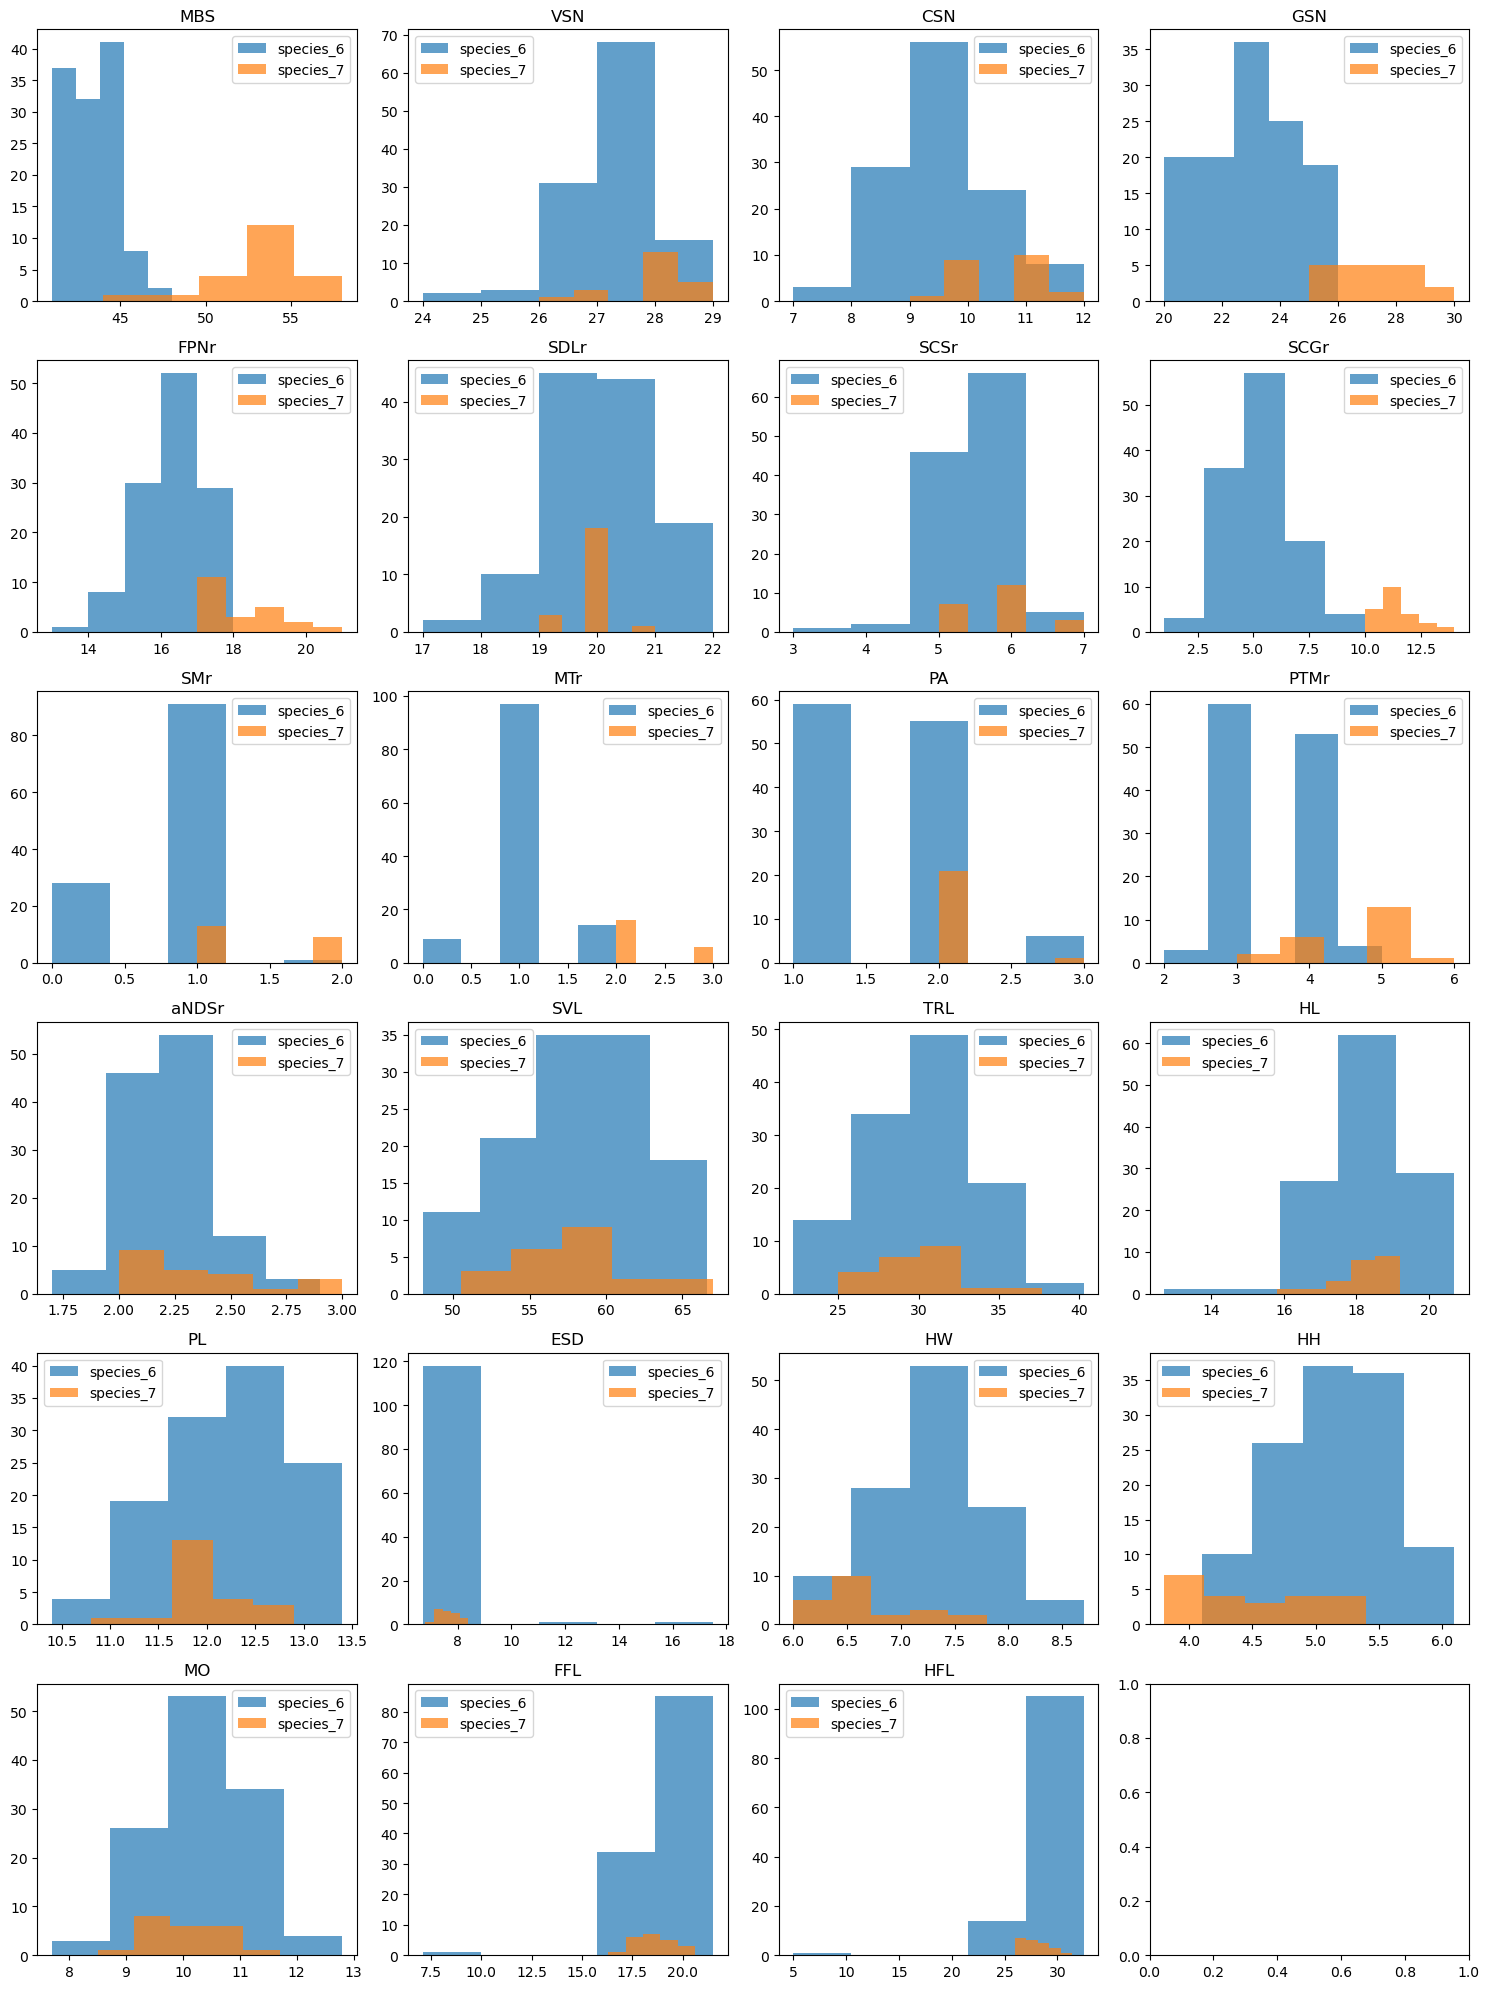

In [7]:
df = pd.read_csv("Ящерицы_данные.csv", sep=';')
cols = []
for i in df.columns:
    if i in ['Species_num', 'Sex', 'Sex_num']:
        continue
    else:
        cols.append(i)

# Делим по виду
species_6 = df[df['Species_num'] == 6]
species_7 = df[df['Species_num'] == 7]

# Создаем figure
fig, axes = plt.subplots(int(np.ceil(len(cols)/4)), 4, figsize=(15,20))

axes = axes.flatten()

# Гистограммы
for i, col in enumerate(cols):
    ax = axes[i]
    ax.hist(species_6[col].dropna(), bins=5, alpha=0.7, label='species_6')
    ax.hist(species_7[col].dropna(), bins=5, alpha=0.7, label='species_7')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

Обнаружен признак, который точно описывает различия между группами - SCGr.

Таким образом, если SCGr < 10, то определяем как вид 6, иначе - вид 7

In [8]:
df = pd.read_csv("Ящерицы_данные.csv", sep=';')

# Присваиваем "1" тем, кто прошел условие, и 0 в противном случае
df['pred_species_6'] = np.where(df['SCGr'] < 10, 1, 0)
df['pred_species_7'] = np.where(df['SCGr'] >= 10, 2, 0)

# Матрица
a = np.sum((df['pred_species_6'] == 1) & (df['Species_num'] == 6))
b = np.sum((df['pred_species_6'] == 1) & (df['Species_num'] == 7))
c = np.sum((df['pred_species_7'] == 2) & (df['Species_num'] == 6))
d = np.sum((df['pred_species_7'] == 2) & (df['Species_num'] == 7))

table = pd.DataFrame([[a, b], [c, d]],
    index = ['Классифицирован как вид №6', 'Классифицирован как вид №7'],
    columns = ['На самом деле вид №6', 'На самом деле виды №7'])

print('\nМатрица:')
table


Матрица:


,На самом деле вид №6,На самом деле виды №7
Классифицирован как вид №6,119,0
Классифицирован как вид №7,1,22


## Поиск критерия для групп 1 и 2

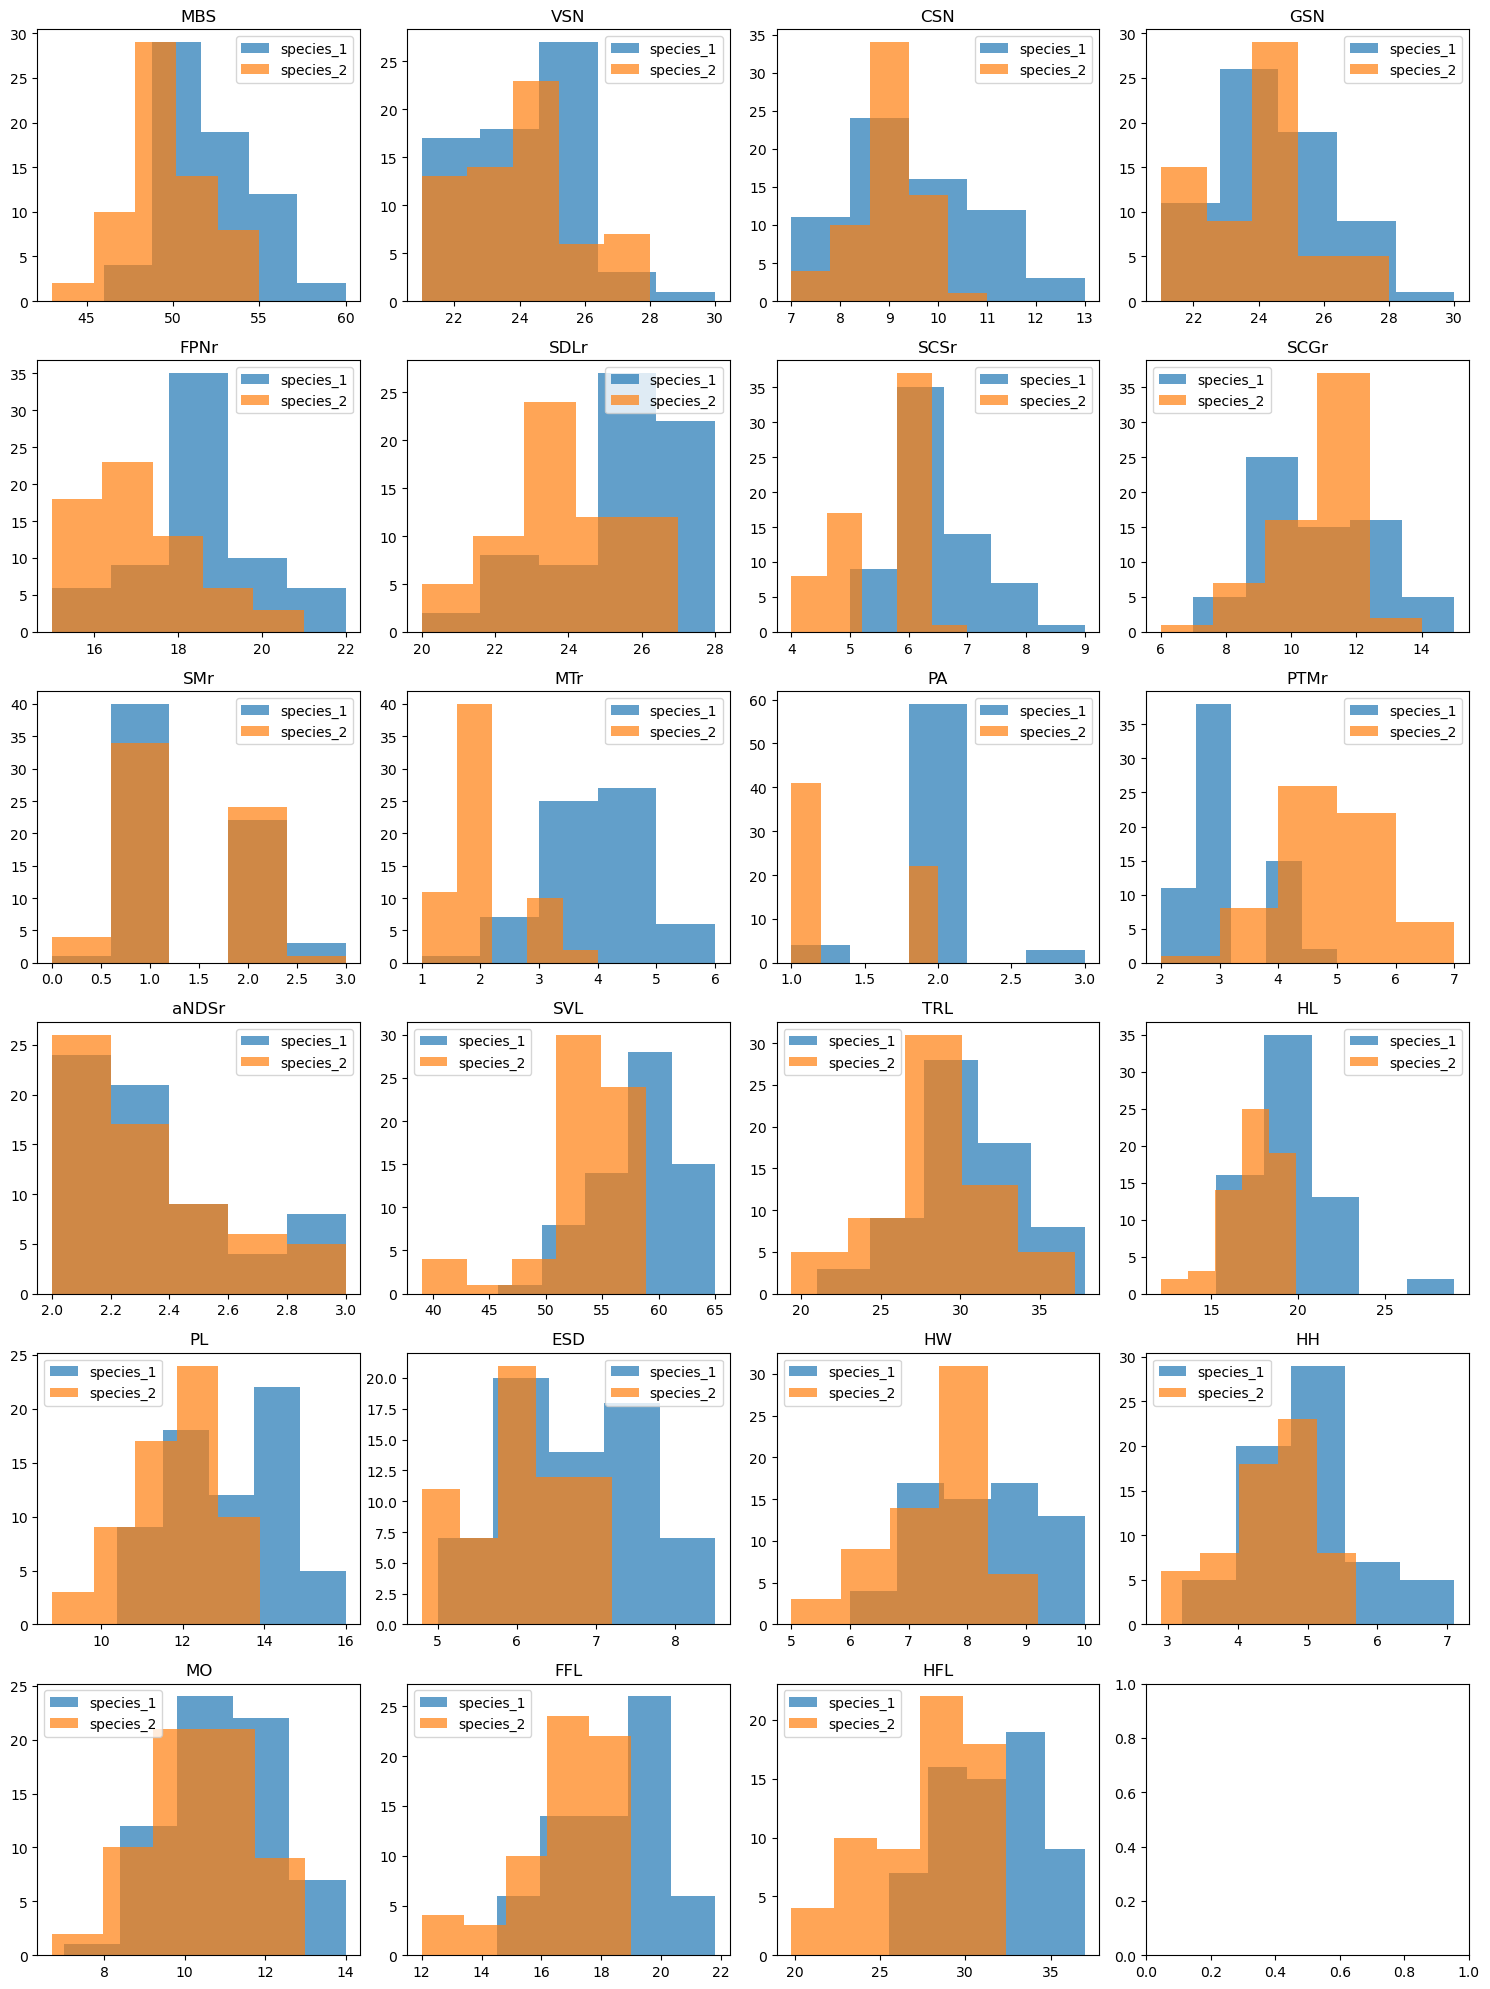

In [9]:
df = pd.read_csv("Ящерицы_данные.csv", sep=';')
cols = []
for i in df.columns:
    if i in ['Species_num', 'Sex', 'Sex_num']:
        continue
    else:
        cols.append(i)

# Делим по виду
species_1 = df[df['Species_num'] == 1]
species_2 = df[df['Species_num'] == 2]

# Создаем figure
fig, axes = plt.subplots(int(np.ceil(len(cols)/4)), 4, figsize=(15,20))

axes = axes.flatten()

# Гистограммы
for i, col in enumerate(cols):
    ax = axes[i]
    ax.hist(species_1[col].dropna(), bins=5, alpha=0.7, label='species_1')
    ax.hist(species_2[col].dropna(), bins=5, alpha=0.7, label='species_2')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

Значимых отличий не обнаружено

## Поиск критерия для групп 3, 4 и 5

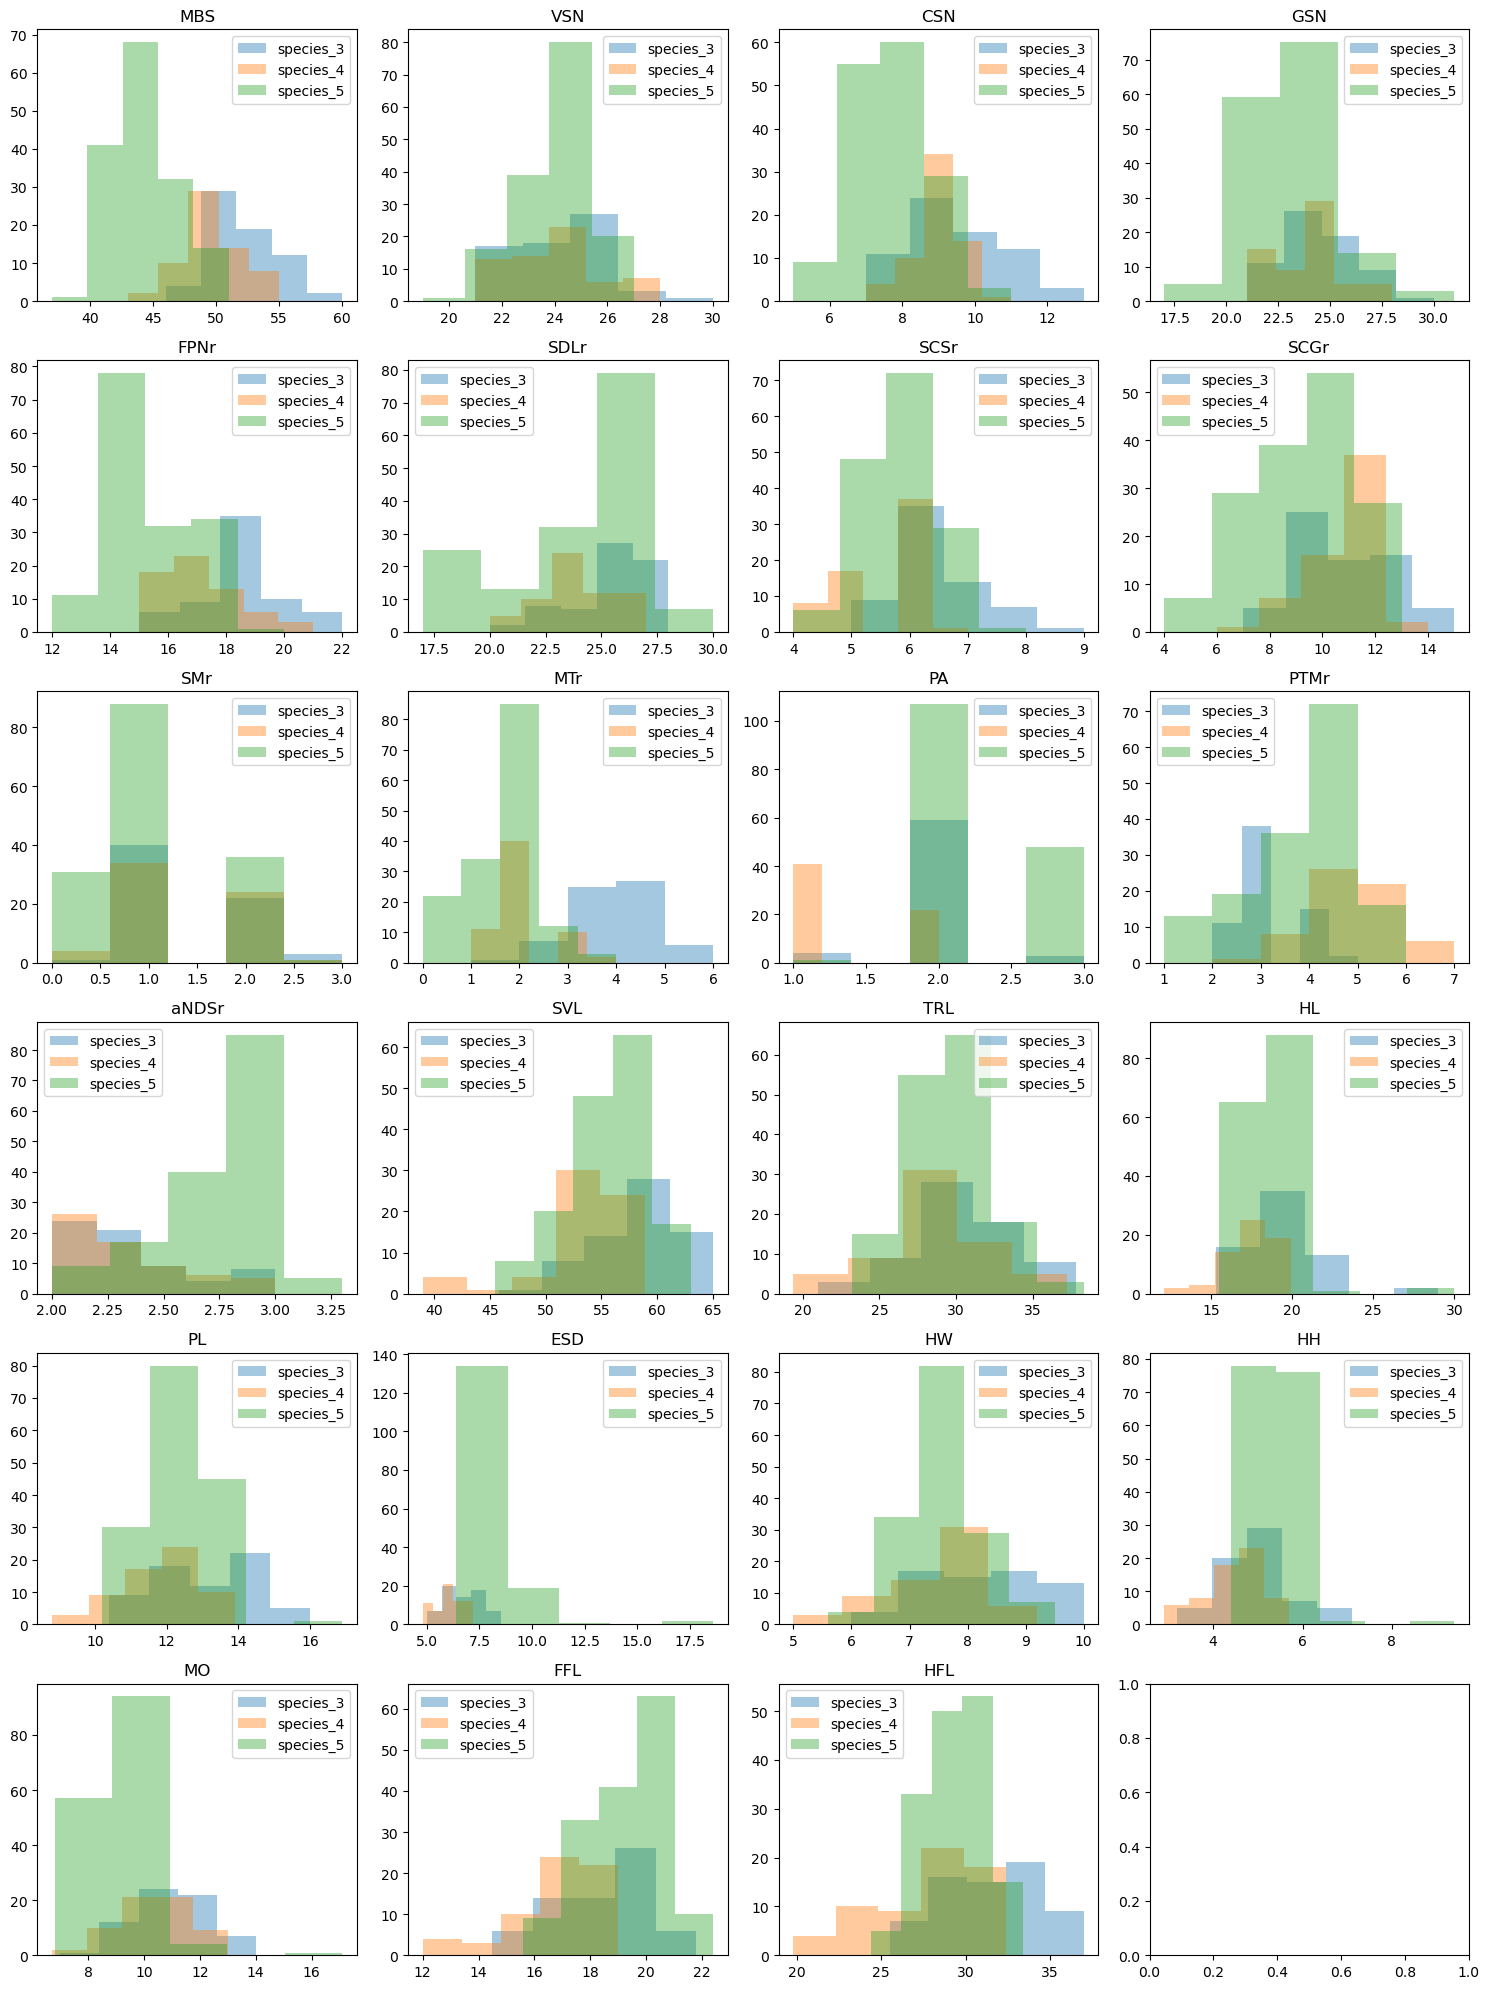

In [10]:
df = pd.read_csv("Ящерицы_данные.csv", sep=';')
cols = []
for i in df.columns:
    if i in ['Species_num', 'Sex', 'Sex_num']:
        continue
    else:
        cols.append(i)

# Делим по виду
species_3 = df[df['Species_num'] == 1]
species_4 = df[df['Species_num'] == 2]
species_5 = df[df['Species_num'] == 3]

# Создаем figure
fig, axes = plt.subplots(int(np.ceil(len(cols)/4)), 4, figsize=(15,20))

axes = axes.flatten()

# Гистограммы
for i, col in enumerate(cols):
    ax = axes[i]
    ax.hist(species_3[col].dropna(), bins=5, alpha=0.4, label='species_3')
    ax.hist(species_4[col].dropna(), bins=5, alpha=0.4, label='species_4')
    ax.hist(species_5[col].dropna(), bins=5, alpha=0.4, label='species_5')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

И здесь тоже значимых различий не обнаружено

## Поиск оптимального решения для всех подгрупп

Для каждой группы видов будем искать признак, который лучше всего разделяет виды между собой. Для этого для каждого вида строится свой «типичный интервал» значений признака - среднее значение +- стандартное отклонение.

Далее каждая ящерица сравнивается с этими интервалами:
* если значение попадает в интервал какого-то вида - относим её к этому виду
* если не попадает ни в один интервал - выбираем вид, чьё среднее значение ближе всего

In [11]:
df = pd.read_csv("Ящерицы_данные.csv", sep=';')

groups = [[6, 7], [1, 2], [3, 4, 5]]

cols = []
for i in df.columns:
    if i in ['Species_num', 'Sex', 'Sex_num']:
        continue
    else:
        cols.append(i)

for group in groups:
    print('Группа видов:', group)
    data = df[df['Species_num'].isin(group)]

    best_acc = 0
    best_feature = None
    best_ranges = None
    best_pred = None
    best_true = None

    # Проверяем каждый признак
    for col in cols:
        temp = data[[col, 'Species_num']].dropna()
        ranges = {}

        # Интервалы для каждого вида
        for sp in group:
            values = temp[temp['Species_num'] == sp][col]
            mean = values.mean()
            std = values.std()
            low = mean - std
            high = mean + std
            ranges[sp] = (low, high)

        # Классификация
        pred = []
        for _, row in temp.iterrows():
            x = row[col]
            predicted = None

            for sp in group:
                low, high = ranges[sp]
                if low <= x <= high:
                    predicted = sp
                    break

            # если не попал никуда —
            # выбираем ближайшее среднее
            if predicted is None:
                distances = {}
                for sp in group:
                    mean = temp[temp['Species_num'] == sp][col].mean()
                    distances[sp] = abs(x - mean)

                predicted = min(distances, key=distances.get)

            pred.append(predicted)

        pred = np.array(pred)
        acc = np.mean(pred == temp['Species_num'])

        # Лучшая переменная
        if acc > best_acc:
            best_acc = acc
            best_feature = col
            best_ranges = ranges
            best_pred = pred
            best_true = temp['Species_num'].values

    # Результат
    print(f'Лучший признак: {best_feature}')
    print('\nИнтервалы:')

    for sp in group:
        low, high = best_ranges[sp]
        print(f'Вид {sp}:{round(low,2)} <= {best_feature} <= {round(high,2)}')
    print('Точность:', round(best_acc, 3))

    # Матрица ошибок
    print('\nМатрица ошибок:')
    matrix = pd.crosstab(best_true, best_pred, rownames=['Реальный вид'], colnames=['Предсказанный вид'])
    print(matrix, '\n\n')

Группа видов: [6, 7]
Лучший признак: MBS

Интервалы:
Вид 6:41.87 <= MBS <= 44.76
Вид 7:50.69 <= MBS <= 56.77
Точность: 0.993

Матрица ошибок:
Предсказанный вид    6   7
Реальный вид              
6                  120   0
7                    1  21 


Группа видов: [1, 2]
Лучший признак: MTr

Интервалы:
Вид 1:2.57 <= MTr <= 4.37
Вид 2:1.37 <= MTr <= 2.73
Точность: 0.845

Матрица ошибок:
Предсказанный вид   1   2
Реальный вид             
1                  58   8
2                  12  51 


Группа видов: [3, 4, 5]
Лучший признак: FPNr

Интервалы:
Вид 3:13.94 <= FPNr <= 16.82
Вид 4:17.11 <= FPNr <= 20.29
Вид 5:7.69 <= FPNr <= 10.23
Точность: 0.908

Матрица ошибок:
Предсказанный вид    3   4   5
Реальный вид                  
3                  140  13   3
4                    8  84   1
5                    0   0  24 




# Задача 5

**Условие**
Создайте критерий или набор критериев, позволяющий наилучшим возможным образом
предсказывать вид или вид и пол ящериц во всей их совокупности (это может понадобиться
биологам, если они не знают место отлова ящерицы).
Вполне возможно, что некоторые пары или группы видов не будут разделяться на основе
имеющихся данных. Приведите наилучший полученный результат, который может в
наибольшей степени помочь биологам.

Для каждого вида вычисляем средние значения всех измеренных признаков. После этого каждая новая ящерица сравнивается со средними значениями всех видов.

Вид определяем по принципу ближайшего сходства:

* считаем расстояние от ящерицы до среднего каждого вида
* ящерицу относим к тому виду, до которого расстояние минимально

Так ищем, на какой вид объект больше всего похож по совокупности всех признаков

In [12]:
df = pd.read_csv('Ящерицы_данные.csv', sep=';')

cols = []
for i in df.columns:
    if i in ['Species_num', 'Sex', 'Sex_num']:
        continue
    else:
        cols.append(i)

# Вычисляем средние признаки для каждого вида
meann = {}
for species in range(1, 9):
    species_data = df[df['Species_num'] == species]
    meann[species] = species_data[cols].mean().values

# Находим ближайшую среднюю
predictions = []
for idx, row in df.iterrows():
    point = row[cols].values
    min_dist = float('inf')
    predicted_species = 1
    
    for species in range(1, 9):
        dist = np.sqrt(np.sum((point - meann[species])**2))
        if dist < min_dist:
            min_dist = dist
            predicted_species = species
    
    predictions.append(predicted_species)

# Матрица ошибок
confusion = pd.crosstab(df['Species_num'], predictions, margins=False)
correct = np.trace(confusion.values)
accuracy = correct / len(df)

print(f"Общая точность: {accuracy:.2%} ({correct}/{len(df)} правильно)")
print("\nТочность по видам:")
for species in range(1, 9):
    species_data = df[df['Species_num'] == species]
    correct_sp = (species_data.index.map(lambda x: predictions[x]) == species).sum()
    total_sp = len(species_data)
    print(f"Вид {species}: {correct_sp}/{total_sp} ({correct_sp/total_sp:.1%})")

Общая точность: 77.30% (436/564 правильно)

Точность по видам:
Вид 1: 49/66 (74.2%)
Вид 2: 49/63 (77.8%)
Вид 3: 125/156 (80.1%)
Вид 4: 70/93 (75.3%)
Вид 5: 22/24 (91.7%)
Вид 6: 86/120 (71.7%)
Вид 7: 19/22 (86.4%)
Вид 8: 16/20 (80.0%)
